In [ ]:
import numpy as np # для работы с многомерными массивами и научными вычислениями
import itertools # для работы с итераторами; для перебора комбинаций, перестановок, произведений множеств и других операций 
from matplotlib import pylab #  для построения графиков
import plotly.graph_objs as go # библиотека для интерактивной визуализации данных.
from plotly.offline import iplot,init_notebook_mode
# iplot — функция для отображения интерактивных графиков прямо в блокноте 
# init_notebook_mode() — включает оффлайн-режим Plotly для работы внутри блокнота
init_notebook_mode(connected=True)

#Класс реализующий простую нейронную сеть
class network:
    # в конструкторе создаётся массив весов размером size+1 (доп. вес для смещения)
    def __init__(self,size): # self - ссылка на сам объект-экземпляр класса
        self.weights=np.zeros(size + 1) # задаём нулевые веса в атрибуте объекта weights
    
    # Функция активации (пороговая)
    def activation_function(self, x):
        return np.array(x >= 0, dtype=int)
    
    # Производная пороговой ФА
    def deviation_activation_function(self, x):
        return 1    
    
    # Функция предсказания 
    def predict(self,inputs):
        # добавляется столбец единичных значений к входным данным, чтобы учесть смещение (bias)
        inputs = np.column_stack((np.ones(len(inputs)),inputs))
        # выполняется матричное умножение входных данных на веса.
        # self.activation_function(...) — применяется функция активации, чтобы получить предсказания для каждого входа.
        return self.activation_function(np.dot(inputs,self.weights.T)) 
    
    # Функция, вычисляющая расстояние Хеминга
    def calculate_E(self,real_outputs,inputs):
        predict_outputs = np.array(self.predict(inputs) >= 0.5, dtype=int) # predict() - метод, возвращающий прогнозы.
        # Сравнивает каждое значение с порогом 0.5, превращая в 1 или 0
        # Превращает результат в массив целых чисел (dtype=int)
        return sum(abs(real_outputs - predict_outputs)) # Складывает все ошибки, получая количество неверных предсказаний — расстояние Хэмминга.
    
    
    # Функция обучения нейросети с использованием дельта-правила Видроу-Хоффа
    def learn(self, inputs, outputs, norm = 0.3, show=True):
        if show==True: # вывод результатов на каждом шаге обучения
            output=[]
            k=0
            E=self.calculate_E(full_outputs,full_inputs) # начальная ошибка сети
            
            while E != 0 and k < 100: # пока ошибка не станет нулевой или пока число итераций < 100
                predict_outputs = self.predict(inputs)
                
                # сохранение промежуточных результатов 
                output.append([k, np.round(self.weights, 2),
                               np.array(self.predict(full_inputs) >= 0.5,
                                        dtype=int), E])
                
                # ошибка, которая является разницей между целевыми выходами и предсказанными.
                error = outputs - predict_outputs 
                
                # Коррекция весов на основе ошибки 
                correction=(norm * np.dot(np.column_stack((np.ones(len(inputs)), inputs)).T,
                                   error * self.deviation_activation_function(inputs))) 
                
                self.weights += correction # w + delta(w)
                # Пересчёт ошибки
                E=self.calculate_E(full_outputs,full_inputs)
                k+=1 

            # Возврат результатов
            output.append([k,np.round(self.weights,2), np.array(self.predict(full_inputs)>0.5, dtype=int), E])
            return output
        
        else: # то же самое, но без сохранения промежуточных результатов для вывода
            k=0
            E=self.calculate_E(full_outputs,full_inputs)
            while E != 0 and k < 100:
                predict_outputs = self.predict(inputs)
                error = outputs-predict_outputs
                correction = (norm * np.dot(np.column_stack((np.ones(len(inputs)), inputs)).T,
                                   error * self.deviation_activation_function(inputs)))
                self.weights += correction # w + delta(w)
                E=self.calculate_E(full_outputs,full_inputs)
                k+=1

In [64]:
#Задание исходных данных
def bool_func(x):
    return (not(not( x[0] | x[1] )) | x[2] | x[3])

# Инициализация списков входных и выходных данных
full_inputs=[]
full_outputs=[]
for i in range(16):
    full_inputs.append(list(map(int, bin(i)[2:].rjust(4,'0'))))
    # list(map(int, ...)) — перевод строки из '0' и '1' в список целых чисел: [0, 0, 1, 0]
    # bin(i)[2:] - перевод i в двоичный вид без префикса 0b (срез, начиная со второго символа)
    # .rjust(4,'0') - дополнение слева нулями до 4 бит
for i in full_inputs:
    full_outputs.append(bool_func(i))
full_inputs = np.array(full_inputs)
full_outputs = np.array(full_outputs)

#Вывод таблицы истинности
print("Таблица истинности:")
for i,j in zip(full_inputs, full_outputs): # zip() — соединяет входы и выходы парами.
    print(i, int(j))


Таблица истинности:
[0 0 0 0] 0
[0 0 0 1] 0
[0 0 1 0] 0
[0 0 1 1] 0
[0 1 0 0] 1
[0 1 0 1] 0
[0 1 1 0] 0
[0 1 1 1] 0
[1 0 0 0] 1
[1 0 0 1] 0
[1 0 1 0] 0
[1 0 1 1] 0
[1 1 0 0] 1
[1 1 0 1] 0
[1 1 1 0] 0
[1 1 1 1] 0


In [65]:
#Обучение сети на всех данных
netw=network(4) # создаётся объект класса network, который представляет нейронную сеть с 4 входами.
output=netw.learn(full_inputs,full_outputs,show=True) # обучаем нейронную сеть на всех данных
# show=True — параметр, который позволяет показывать результаты обучения на каждом шаге (эпохе).

#Вывод результатов
# создаём таблицу с помощью библиотеки Plotly для визуализации:
trace = go.Table(
    # header — определяет названия колонок в таблице
    header = dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    
    # cells — создаём ячейки для данных, используя zip(*output); каждый столбец данных (эпохи) транспонируется
    cells = dict(values = [*list(zip(*output))]) 
)
data = [trace] 
iplot(data, filename = 'basic_table') # отображает таблицу в Jupyter Notebook с помощью Plotly


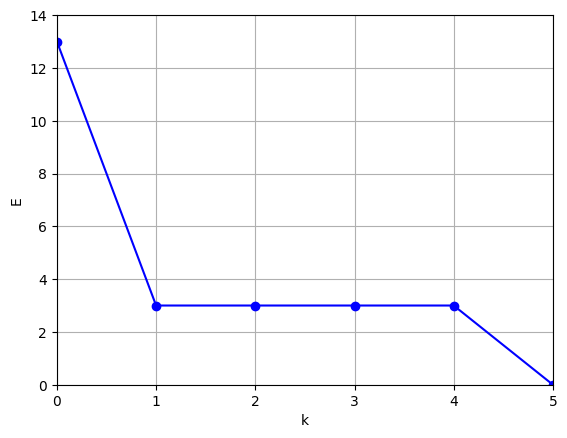

In [66]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Пороговая функция, все данные

# output - спсиок, где каждая запись - информация о текущей эпохе
# i[-1] - последний элемент записи (кортежа) - значение суммар. ошибки
error=[i[-1] for i in output] # из результата обучения извлекается ошибка
pylab.plot(error,'-ob') # строим график: 'o' — круги, 'b' — синий цвет
pylab.xlabel('k') # номер эпохи
pylab.ylabel('E') # ошибка
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()


In [67]:
#Класс для сети с сигмоидальной функцией активации
class new_network(network):

    # Функция активации (сигмоидальная)
    def activation_function(self, x):
        return 1 / (1 + np.exp(-x))
    
    # Производная ФА
    def deviation_activation_function(self, x):
        x = np.column_stack((np.ones(len(x)), x))
        x = np.dot(x, self.weights.T)
        return self.activation_function(x) * (1 - self.activation_function(x))
    
#обучение сети с сигмоидальной функцией на всех данных
netw=new_network(4)
output_sigma=netw.learn(full_inputs,full_outputs,show=True)

#вывод результатов
trace = go.Table(
    header=dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    cells=dict(values=[*list(zip(*output_sigma))])
)
data = [trace] 
iplot(data, filename = 'basic_table')


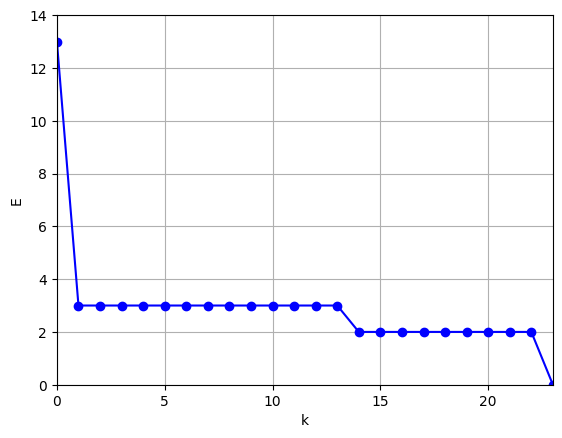

In [68]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Сигмоидальная функция, все данные
error=[i[-1] for i in output_sigma]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()


In [69]:
#Функция для нахождения минимальных входных данных для сети, достаточных для обучения
def find_min_inputs(network):
    for i in range(15,0,-1): # Перебор подмножеств от 15 до 1 элемента
        new_inputs=itertools.combinations(range(16), i)
        for j in new_inputs: # перебор всех возможных сочетаний индексов входов длиной i 
            
            inputs=[]
            outputs=[]
            for i in j:
                # формируем двоичное представление числа (4-битное)
                inputs.append(list(map(int,bin(i)[2:].rjust(4,'0'))))
            for i in inputs:
                # генерируем выходы для поднабора входов через булеву функцию
                outputs.append(bool_func(i))
            
            netw=network(4) # инициализация сети с 4 входами   
            netw.learn(inputs,outputs,norm=0.3) # Обучение сети на выбранном подмножестве

            # Проверка, способна ли сеть корректно предсказывать на всем множестве
            if all(np.array(netw.predict(full_inputs) > 0.5, dtype=int) == full_outputs): 
                # если сеть обучилась успешно, сохраняем веса и индексы входов
                min_inputs={'weights': netw.weights,'inputs': j}
                break
    return min_inputs

#Функция для проверки правильности вычисленных минимальных входных данных
def check_min_inputs(network, min_inputs):
    
    inputs=[]
    outputs=[]
    
    # Восстанавливаем входные векторы из сохранённых индексов
    for i in min_inputs['inputs']:
        inputs.append(list(map(int,bin(i)[2:].rjust(4,'0'))))
    
    # Формируем целевые выходы 
    for i in inputs:
        outputs.append(bool_func(i)) 
    
    inputs = np.array(inputs)
    outputs = np.array(outputs)
    
    print('input sample ',*inputs)
    
    netw = network(4)
    output = netw.learn(inputs,outputs,show=True) # обучение сети на найденном минимальном наборе 

    print('weights:', min_inputs['weights'])
    print('network outputs ',np.array(netw.predict(full_inputs)>0.5, dtype=int))
    print('real outputs   ', full_outputs)
    
    #вывод результатов
    trace = go.Table(
        header=dict(values=['Номер эпохи k', 
                            'Вектор весов w',
                            'Выходной вектор y',
                            'Суммарная ошибка E']),
        cells=dict(values=[*list(zip(*output))])
    )
    data = [trace]
    iplot(data, filename = 'basic_table')
    return output


In [70]:
#Вычисление минимального набора векторов и вывод результатов
#Пороговая функция
min_inputs = find_min_inputs(network)
output = check_min_inputs(network, min_inputs)


input sample  [0 0 0 0] [1 1 0 0] [1 1 1 1]
weights: [-0.3  0.3  0.3 -0.6 -0.6]
network outputs  [0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0]
real outputs    [False False False False  True False False False  True False False False
  True False False False]


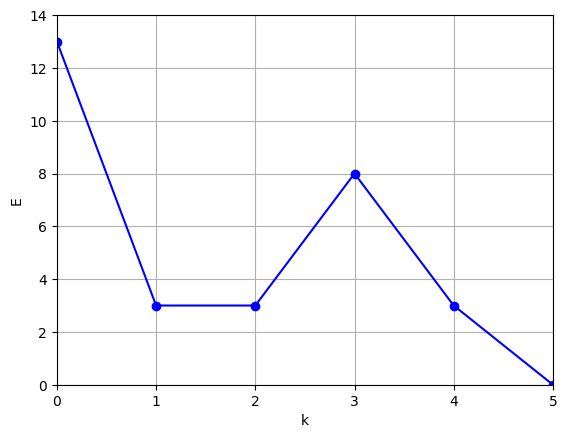

In [71]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Пороговая функция, минимальный набор данных
error=[i[-1] for i in output]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()


In [72]:
#Вычисление минимального набора векторов и вывод результатов
#Сигмоидальная функция
min_inputs = find_min_inputs(new_network)
output_sigma = check_min_inputs(new_network, min_inputs)


input sample  [0 0 0 1] [1 1 0 0] [1 1 1 0]
weights: [-0.45842605  0.46081754  0.46081754 -1.24989078 -0.91924358]
network outputs  [0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0]
real outputs    [False False False False  True False False False  True False False False
  True False False False]


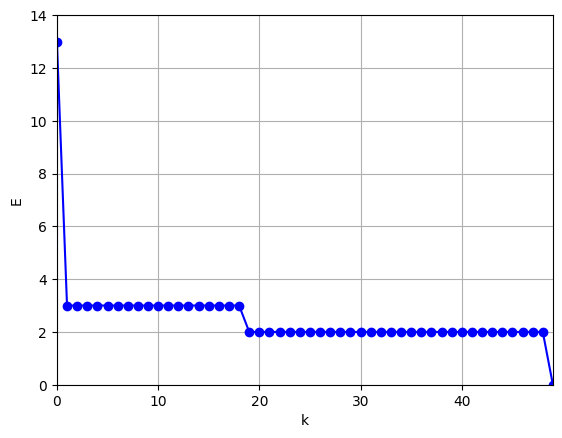

In [73]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Сигмоидальная функция, минимальный набор данных
error=[i[-1] for i in output_sigma]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()
